In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

In [ ]:
client = Client("IRIS")

network = "*"
station = "FNO"
location = "*"
channel = "*"

endtime = UTCDateTime.now()
starttime = endtime - 3600  # past hour

st = client.get_waveforms(
    network=network,
    station=station,
    location=location,
    channel=channel,
    starttime=starttime,
    endtime=endtime,
)
print(st)

3 Trace(s) in Stream:
OK.FNO..HHE | 2026-09-07T20:32:12.870000Z - 2026-09-07T21:32:09.150000Z | 100.0 Hz, 359629 samples
OK.FNO..HHN | 2026-09-07T20:32:12.870000Z - 2026-09-07T21:32:10.210000Z | 100.0 Hz, 359735 samples
OK.FNO..HHZ | 2026-09-07T20:32:12.870000Z - 2026-09-07T21:32:09.620000Z | 100.0 Hz, 359676 samples


In [ ]:
st.detrend("demean")
st.detrend("linear")
st.filter("bandpass", freqmin=1.0, freqmax=10.0, corners=4, zerophase=True)

3 Trace(s) in Stream:
OK.FNO..HHE | 2026-09-07T20:32:12.870000Z - 2026-09-07T21:32:09.150000Z | 100.0 Hz, 359629 samples
OK.FNO..HHN | 2026-09-07T20:32:12.870000Z - 2026-09-07T21:32:10.210000Z | 100.0 Hz, 359735 samples
OK.FNO..HHZ | 2026-09-07T20:32:12.870000Z - 2026-09-07T21:32:09.620000Z | 100.0 Hz, 359676 samples

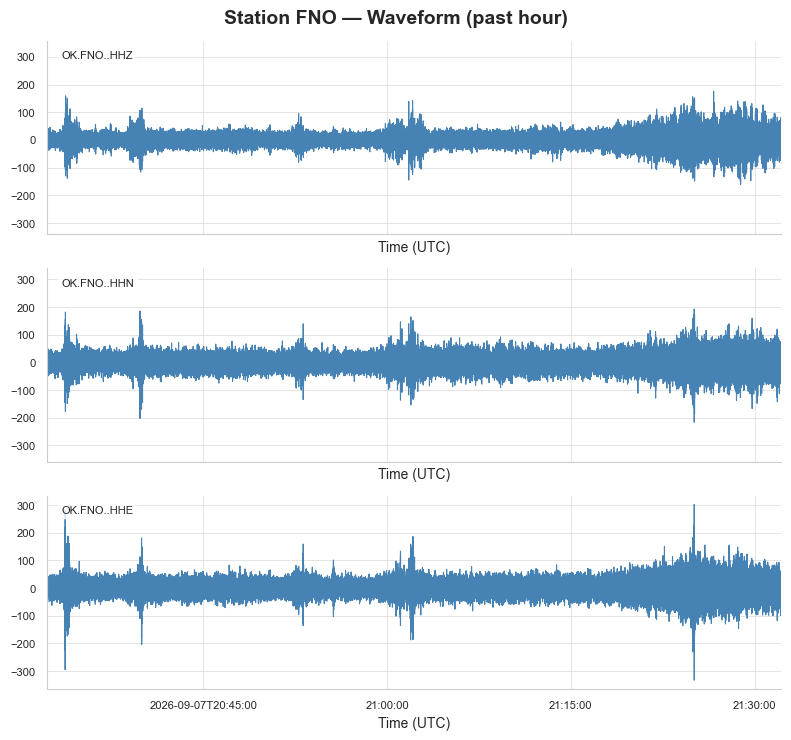

In [ ]:
sns.set_theme(style="whitegrid", palette="deep", context="paper")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "grid.color": "0.85",
})

fig = st.plot(color="steelblue", linewidth=0.8, handle=True, show=False)
fig.suptitle(f"Station {station} — Waveform (past hour)", fontsize=14, fontweight="bold")

for ax in fig.axes:
    ax.set_ylabel(ax.get_ylabel(), fontsize=10)
    ax.set_xlabel("Time (UTC)", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, linewidth=0.5, color="0.85")
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()